# 1. Library Preparation

In [ ]:
# Import libraries
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import shap
import requests
import pandas as pd
import numpy as np
import sklearn
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
import sweetviz as sv  
from pycaret.classification import *
from sklearn.ensemble import ExtraTreesClassifier  
from sklearn.model_selection import RandomizedSearchCV

# 2. Data Extraction

In [2]:
# 1. Setup Session
session = requests.Session()
session.headers.update({
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'})

# DJIA Stocks
djia_tickers = [
    'AAPL', 'AMGN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'DOW', 
    'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 
    'MRK', 'MSFT', 'NKE', 'PG', 'TRV', 'UNH', 'V', 'VZ', 'WMT', 'AMZN']
index_ticker = '^DJI'

# 2. Extract Index Data
def extract_market_index(start_date):
    end_date = datetime.now()
    
    market_data = yf.download(
        index_ticker, 
        start=start_date,
        end=end_date.strftime('%Y-%m-%d'), 
        progress=False,
        session=session)
    
    market_df = market_data[['Close']].copy()
    market_df.columns = ['DJIA_Close']
    
    market_df.reset_index(inplace=True)
    return market_df

# 3. Extract OHLCV
def extract_OHLCV(tickers, start_date):
    end_date = datetime.now()

    data = yf.download(
        tickers,
        start=start_date,
        end=end_date.strftime('%Y-%m-%d'),
        group_by='ticker',
        progress=False,
        session=session)

    final_list = []
    for ticker in tickers:
        try:
            if ticker in data and not data[ticker].dropna(how='all').empty:
                df_ticker = data[ticker].copy()
                df_ticker.reset_index(inplace=True)
                df_ticker['Ticker'] = ticker
                df_ticker = df_ticker[['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume']]
                final_list.append(df_ticker)
        except Exception as e:
            print(f" [!] Error {ticker}: {e}")

    if final_list:
        return pd.concat(final_list, ignore_index=True)
    return pd.DataFrame()

# Execution
if __name__ == "__main__":
    start_date = "1992-01-01"
    
    df_market = extract_market_index(start_date=start_date)
    
    df_technicals = extract_OHLCV(djia_tickers, start_date=start_date)

In [3]:
# Check Dataset
df_market

,Date,DJIA_Close
0,1992-01-02,3172.399902
1,1992-01-03,3201.500000
2,1992-01-06,3200.100098
3,1992-01-07,3204.800049
4,1992-01-08,3203.899902
...,...,...
8668,2026-06-08,50786.011719
8669,2026-06-09,50872.109375
8670,2026-06-10,49918.781250
8671,2026-06-11,50848.750000


In [4]:
# Check Dataset
df_technicals

Price,Date,Ticker,Open,High,Low,Close,Volume
0,1992-01-02,AAPL,0.398359,0.426940,0.396573,0.425154,233632000.0
1,1992-01-03,AAPL,0.428727,0.430513,0.416222,0.421582,190254400.0
2,1992-01-06,AAPL,0.419795,0.421582,0.412650,0.414436,114240000.0
3,1992-01-07,AAPL,0.410863,0.425154,0.410863,0.422475,141467200.0
4,1992-01-08,AAPL,0.418008,0.437659,0.418008,0.432300,232747200.0
...,...,...,...,...,...,...,...
260185,2026-06-08,AMZN,246.679993,249.419998,243.360001,245.220001,33899500.0
260186,2026-06-09,AMZN,247.729996,250.429993,240.399994,244.190002,44425400.0
260187,2026-06-10,AMZN,243.610001,244.070007,237.449997,238.000000,38590200.0
260188,2026-06-11,AMZN,237.929993,242.139999,235.179993,241.509995,41335400.0


# 3. Data Wrangling

In [5]:
# Data Condition Check
# Market Data
report = sv.analyze(df_market)
report.show_html('eda/Raw Market Data EDA.html')

# Technical Data
report = sv.analyze(df_technicals)
report.show_html('eda/Raw Technical Data EDA.html')

                                             |          | [  0%]   00:00 -> (? left)

Report eda/Raw Market Data EDA.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


                                             |          | [  0%]   00:00 -> (? left)

Report eda/Raw Technical Data EDA.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [6]:
# Check Hypothesis of NaN Data, namely NaN representing unavailable data before listing date
# Check First Date of Listing
df_sorted = df_technicals.sort_values(['Ticker', 'Date']).copy()
df_valid = df_sorted.dropna(subset=['Close']) # "Close" is choosen for checking NaN on the line
first_dates = df_valid.groupby('Ticker')['Date'].min().reset_index()
first_dates.rename(columns={'Date': 'First_Valid_Date'}, inplace=True)

print("First-Listed Date")
display(first_dates.sort_values(by="First_Valid_Date"))
print("-" * 50)

# Check our hypothesis
df_merged = df_sorted.merge(first_dates, on='Ticker')
df_after_first = df_merged[df_merged['Date'] >= df_merged['First_Valid_Date']]
nan_after_first = df_after_first[df_after_first[df_merged.columns.to_list()].isna().any(axis=1)]

print("Investigation Result")
if nan_after_first.empty:
    print("✅ Hypothesis is accepted.")
else:
    print("⚠️ Hypothesis is rejected")
    print(nan_after_first[['Date', 'Ticker'] + df_merged.columns.to_list()])

First-Listed Date


,Ticker,First_Valid_Date
0,AAPL,1992-01-02
26,UNH,1992-01-02
25,TRV,1992-01-02
24,PG,1992-01-02
23,NKE,1992-01-02
22,MSFT,1992-01-02
21,MRK,1992-01-02
20,MMM,1992-01-02
19,MCD,1992-01-02
18,KO,1992-01-02


--------------------------------------------------
Investigation Result
✅ Hypothesis is accepted.


# 4. Feature Engineering

## Feature Creation

In [7]:
# Price & Return Characteristics
def add_price_features(df):
    df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)
    g = df.groupby("Ticker")["Close"]

    # Return
    df["return_1d"]  = g.pct_change(1)
    df["return_3d"]  = g.pct_change(3)
    df["return_5d"]  = g.pct_change(5)
    df["return_10d"] = g.pct_change(10)
    df["return_20d"] = g.pct_change(20)

    # Gap Price
    prev_close = g.shift(1)
    df["overnight_gap"] = (df["Open"] - prev_close) / prev_close

    # Candle Body & Shadow
    df["body_size"]    = (df["Close"] - df["Open"]).abs() / df["Open"]
    df["upper_shadow"]  = (df["High"] - df[["Close","Open"]].max(axis=1)) / df["Open"]
    df["lower_shadow"]  = (df[["Close","Open"]].min(axis=1) - df["Low"]) / df["Open"]
    df["hl_range"]     = (df["High"] - df["Low"]) / df["Open"]   # intraday range

    # Close Position
    hl = df["High"] - df["Low"]
    df["close_position"] = (df["Close"] - df["Low"]) / hl.replace(0, np.nan)
    return df

In [8]:
# Moving Averanges & Trend Characteristics
def add_ma_features(df):
    # SMA and EMA Calculation
    g_close = df.groupby("Ticker")["Close"]
    
    windows = [5, 10, 20, 50, 200]
    for w in windows:
        df[f"temp_sma_{w}"] = g_close.transform(lambda x: x.rolling(w).mean())
        df[f"temp_ema_{w}"] = g_close.transform(lambda x: x.ewm(span=w, adjust=False).mean())
        
    # SMA Distance
    for w in windows:
        df[f"dist_sma_{w}"] = (df["Close"] - df[f"temp_sma_{w}"]) / df[f"temp_sma_{w}"]
        df[f"dist_ema_{w}"] = (df["Close"] - df[f"temp_ema_{w}"]) / df[f"temp_ema_{w}"]

    # Micro Trend
    df["crossover_ema_5_20"] = df["temp_ema_5"] / df["temp_ema_20"]
    
    # Macro Trend
    df["crossover_sma_50_200"] = df["temp_sma_50"] / df["temp_sma_200"]
    
    # Market Regime
    df["bullish_regime"] = (df["temp_sma_50"] > df["temp_sma_200"]).astype(int)

    # SMA Slope
    g_sma20 = df.groupby("Ticker")["temp_sma_20"]
    df["sma20_slope_5d"] = g_sma20.diff(5) / g_sma20.shift(5)
    
    # Cleaning
    cols_to_drop = [col for col in df.columns if col.startswith('temp_')]
    df = df.drop(columns=cols_to_drop)
    
    return df

In [9]:
# Volatility Characteristics
def add_volatility_features(df):
    # Rolling std return
    for w in [5, 10, 20]:
        df[f"volatility_{w}d"] = df.groupby("Ticker")["return_1d"].transform(lambda x: x.rolling(w).std())
        
    # ATR (Average True Range)
    prev_close = df.groupby("Ticker")["Close"].shift(1)
    
    high_low = df["High"] - df["Low"]
    high_prev_close = (df["High"] - prev_close).abs()
    low_prev_close = (df["Low"] - prev_close).abs()
    
    tr = pd.concat([high_low, high_prev_close, low_prev_close], axis=1).max(axis=1)
    
    df["atr_14"] = tr.groupby(df["Ticker"]).transform(lambda x: x.ewm(alpha=1/14, adjust=False).mean())
    df["atr_pct"] = df["atr_14"] / df["Close"]
    
    # Volatility Ratio
    df["vol_ratio_5_20"] = np.where(
        df["volatility_20d"] == 0, 
        np.nan, 
        df["volatility_5d"] / df["volatility_20d"])
    return df

In [10]:
# Momentum & Oscillator Characteristics
def add_momentum_features(df):
    close = df["Close"]
    
    # RSI (Wilder's Smoothing)
    delta = df.groupby("Ticker")["Close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    
    ema_gain = gain.groupby(df["Ticker"]).transform(lambda x: x.ewm(alpha=1/14, adjust=False).mean())
    ema_loss = loss.groupby(df["Ticker"]).transform(lambda x: x.ewm(alpha=1/14, adjust=False).mean())
    
    rs = ema_gain / ema_loss.replace(0, np.nan)
    df["rsi_14"] = 100 - (100 / (1 + rs))
    
    # Stochastic %K & %D
    low14 = df.groupby("Ticker")["Low"].transform(lambda x: x.rolling(14).min())
    high14 = df.groupby("Ticker")["High"].transform(lambda x: x.rolling(14).max())
    
    df["stoch_k"] = 100 * (close - low14) / (high14 - low14).replace(0, np.nan)
    df["stoch_d"] = df.groupby("Ticker")["stoch_k"].transform(lambda x: x.rolling(3).mean())
    
    # MACD
    ema12 = df.groupby("Ticker")["Close"].transform(lambda x: x.ewm(span=12, adjust=False).mean())
    ema26 = df.groupby("Ticker")["Close"].transform(lambda x: x.ewm(span=26, adjust=False).mean())
    df["macd"] = ema12 - ema26
    df["macd_signal"] = df.groupby("Ticker")["macd"].transform(lambda x: x.ewm(span=9, adjust=False).mean())
    df["macd_hist"] = df["macd"] - df["macd_signal"]
    
    prev_macd = df.groupby("Ticker")["macd"].shift(1)
    prev_signal = df.groupby("Ticker")["macd_signal"].shift(1)
    df["macd_cross_up"] = ((df["macd"] > df["macd_signal"]) & (prev_macd <= prev_signal)).astype(int)
    
    # Rate of Change (ROC)
    for w in [5, 10, 20]:
        df[f"roc_{w}"] = df.groupby("Ticker")["Close"].transform(lambda x: (x - x.shift(w)) / x.shift(w).replace(0, np.nan))
        
    # Williams %R
    df["williams_r"] = -100 * (high14 - close) / (high14 - low14).replace(0, np.nan)
    
    # CCI (Commodity Channel Index)
    tp = (df["High"] + df["Low"] + close) / 3
    sma_tp = tp.groupby(df["Ticker"]).transform(lambda x: x.rolling(20).mean())
    
    mad = tp.groupby(df["Ticker"]).transform(lambda x: x.rolling(20).apply(lambda y: np.mean(np.abs(y - np.mean(y))), raw=True))
    df["cci_20"] = (tp - sma_tp) / (0.015 * mad.replace(0, np.nan))
    return df

In [11]:
# Volume Characteristics
def add_volume_features(df):
    g_vol = df.groupby("Ticker")["Volume"]
    
    # Volume Characteristics
    df["vol_sma20"] = g_vol.transform(lambda x: x.rolling(20).mean())
    df["vol_ratio"] = df["Volume"] / df["vol_sma20"].replace(0, np.nan)
    df["vol_change_1d"] = g_vol.pct_change(1)
    
    # On-Balance Volume (OBV)
    price_sign = np.sign(df.groupby("Ticker")["Close"].diff())
    df["obv"] = (price_sign * df["Volume"]).groupby(df["Ticker"]).cumsum()
    
    # Volume Price Trend (VPT)
    ret = df.groupby("Ticker")["Close"].pct_change()
    df["vpt"] = (ret * df["Volume"]).groupby(df["Ticker"]).cumsum()
    
    # Accumulation/Distribution Line (ADL)
    hl = df["High"] - df["Low"]
    clv = ((df["Close"] - df["Low"]) - (df["High"] - df["Close"])) / hl.replace(0, np.nan)
    clv_vol = clv * df["Volume"]
    
    df["adl"] = clv_vol.groupby(df["Ticker"]).cumsum()
    
    # Chaikin Money Flow (20-period)
    sum_clv_vol = clv_vol.groupby(df["Ticker"]).transform(lambda x: x.rolling(20).sum())
    sum_vol = g_vol.transform(lambda x: x.rolling(20).sum())
    
    df["cmf_20"] = sum_clv_vol / sum_vol.replace(0, np.nan) 
    return df

In [12]:
# Bollinger Bands Characteristics
def add_bollinger_features(df):
# SMA and STD Calculation
    g_close = df.groupby("Ticker")["Close"]
    sma20 = g_close.transform(lambda x: x.rolling(20).mean())
    std20 = g_close.transform(lambda x: x.rolling(20).std())
    
    # Upper and Lower Bands Calculation
    bb_upper = sma20 + (2 * std20)
    bb_lower = sma20 - (2 * std20)
    
    # Bandwidth dan %B Calculation
    df["bb_width"] = (bb_upper - bb_lower) / sma20
    df["bb_pct"] = (df["Close"] - bb_lower) / (bb_upper - bb_lower).replace(0, np.nan)
    
    # Bollinger Squeeze
    rolling_quantile = df.groupby("Ticker")["bb_width"].transform(lambda x: x.rolling(20).quantile(0.2))
    df["bb_squeeze"] = (df["bb_width"] < rolling_quantile).astype(int)
    
    return df

In [13]:
# DJIA Index Characteristics
def add_market_features(df, df_market):
    # Market Index Characteristics
    mkt = df_market.copy().sort_values("Date")
    mkt["mkt_return_1d"]  = mkt["DJIA_Close"].pct_change(1)
    mkt["mkt_return_5d"]  = mkt["DJIA_Close"].pct_change(5)
    mkt["mkt_return_20d"] = mkt["DJIA_Close"].pct_change(20)
    mkt["mkt_sma50"]      = mkt["DJIA_Close"].rolling(50).mean()
    mkt["mkt_sma200"]     = mkt["DJIA_Close"].rolling(200).mean()
    mkt["mkt_above_sma200"] = (mkt["DJIA_Close"] > mkt["mkt_sma200"]).astype(int)
    mkt["mkt_vol_20d"]    = mkt["mkt_return_1d"].rolling(20).std()
    
    mkt_cols = ["Date", "mkt_return_1d", "mkt_return_5d", "mkt_return_20d", 
                "mkt_above_sma200", "mkt_vol_20d"]
    df = df.merge(mkt[mkt_cols], on="Date", how="left")
    
    var_mkt = df.groupby("Ticker")["mkt_return_1d"].transform(lambda x: x.rolling(60).var())
    
    # Rolling Covariance
    def calc_cov(group):
        return group["return_1d"].rolling(60).cov(group["mkt_return_1d"])
        
    cov_rm = df.groupby("Ticker").apply(calc_cov).reset_index(level=0, drop=True)
    
    # Beta, Alpha, dan Relative Strength
    df["beta_60d"] = cov_rm / var_mkt.replace(0, np.nan)
    df["alpha_60d"] = df["return_1d"] - (df["beta_60d"] * df["mkt_return_1d"])
    df["rs_vs_mkt_20d"] = df["return_20d"] - df["mkt_return_20d"]
    return df

In [14]:
# Resistance Characteristics
def add_pivot_features(df):
    g = df.groupby("Ticker")
    high_prev = g["High"].shift(1)
    low_prev = g["Low"].shift(1)
    close_prev = g["Close"].shift(1)
    
    # Pivot Point
    pivot = (high_prev + low_prev + close_prev) / 3
    r1 = (2 * pivot) - low_prev
    s1 = (2 * pivot) - high_prev
    r2 = pivot + (high_prev - low_prev)
    s2 = pivot - (high_prev - low_prev)
    
    # Resistance Characteristics
    cur_close = df["Close"]
    df["dist_pivot"] = (cur_close - pivot) / pivot.replace(0, np.nan)
    df["dist_r1"] = (r1 - cur_close) / cur_close.replace(0, np.nan)
    df["dist_s1"] = (cur_close - s1) / cur_close.replace(0, np.nan)
    df["dist_r2"] = (r2 - cur_close) / cur_close.replace(0, np.nan)
    df["dist_s2"] = (cur_close - s2) / cur_close.replace(0, np.nan)
    return df

## Label Creation

In [15]:
# Label Creation
def create_label(df, horizon=5, threshold=0.03):
    df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)
    future_close = df.groupby("Ticker")["Close"].shift(-horizon)
    df["target"] = ((future_close / df["Close"] - 1) > threshold).astype(int)
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.drop(columns=['Open', 'High', 'Low', 'Close', 'Volume', 'vol_sma20'])
    df = df.dropna()
    return df

## Exploratory Data Analysis

In [16]:
# Implement Functions
df_technicals = add_price_features(df_technicals)
df_technicals = add_ma_features(df_technicals)
df_technicals = add_volatility_features(df_technicals)
df_technicals = add_momentum_features(df_technicals)
df_technicals = add_volume_features(df_technicals)
df_technicals = add_bollinger_features(df_technicals)
df_technicals = add_market_features(df_technicals, df_market)
df_technicals = add_pivot_features(df_technicals)
df_technicals = create_label(df_technicals)

# Data Condition Check
report = sv.analyze(df_technicals)
report.show_html('eda/Processed Data EDA.html')

                                             |          | [  0%]   00:00 -> (? left)

Report eda/Processed Data EDA.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [17]:
# Check Skew Values
num_cols = list(df_technicals.select_dtypes(exclude=['object', 'datetime']).columns)
list_item= []

for col in num_cols:
    skew_val = round(df_technicals[col].skew(), 1)
    if abs(skew_val) <= 0.5:
        label = 'normal'
    else:
        label = 'skewed'
    list_item.append([col, skew_val, label])

# Dataframe
df_skew = pd.DataFrame(columns=['Columns', 'Skew Value', 'Distribution'], data=list_item)
df_skew.sort_values(by="Skew Value", ascending=True). tail(25)

,Columns,Skew Value,Distribution
4,return_20d,0.7,skewed
51,bb_squeeze,0.9,skewed
19,dist_sma_200,1.0,skewed
59,rs_vs_mkt_20d,1.2,skewed
65,target,1.5,skewed
64,dist_s2,1.7,skewed
61,dist_r1,2.5,skewed
27,volatility_20d,2.7,skewed
26,volatility_10d,2.9,skewed
63,dist_r2,3.0,skewed


## Data Split

In [18]:
# Train and Test Period
df_technicals = df_technicals.sort_values("Date").reset_index(drop=True)
split_date = "2022-01-01"
train_mask = df_technicals["Date"] < split_date
test_mask = df_technicals["Date"] >= split_date

# Split Target
cols_to_drop = ['target', 'Date', 'Ticker'] 
X_train = df_technicals[train_mask].drop(columns=cols_to_drop, errors='ignore')
y_train = df_technicals[train_mask]['target']

X_test = df_technicals[test_mask].drop(columns=cols_to_drop, errors='ignore')
y_test = df_technicals[test_mask]['target']

# 5. Model & Hyperparameter Experiment

In [19]:
# Model Comparison
clf_setup = setup(
    data = X_train, 
    target = y_train, 
    session_id = 40,
    normalize = True,
    transformation = False,
    fix_imbalance = True)

best_model = compare_models()

,Description,Value
0,Session id,40
1,Target,target
2,Target type,Binary
3,Original data shape,"(203456, 66)"
4,Transformed data shape,"(289063, 66)"
5,Transformed train set shape,"(228026, 66)"
6,Transformed test set shape,"(61037, 66)"
7,Numeric features,65
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dummy,Dummy Classifier,0.8005,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,3.9750
et,Extra Trees Classifier,0.7977,0.7161,0.2480,0.4860,0.3284,0.2237,0.2414,37.3100
rf,Random Forest Classifier,0.7881,0.7046,0.2438,0.4434,0.3145,0.2015,0.2142,120.7160
catboost,CatBoost Classifier,0.7806,0.6919,0.2691,0.4220,0.3285,0.2050,0.2125,94.9410
xgboost,Extreme Gradient Boosting,0.7655,0.6766,0.2851,0.3824,0.3266,0.1882,0.1913,13.3480
lightgbm,Light Gradient Boosting Machine,0.7562,0.6620,0.2682,0.3535,0.3049,0.1605,0.1628,11.3440
gbc,Gradient Boosting Classifier,0.7322,0.6473,0.3149,0.3239,0.3193,0.1527,0.1527,348.5760
nb,Naive Bayes,0.7036,0.6399,0.4021,0.3116,0.3511,0.1630,0.1653,3.8080
ada,Ada Boost Classifier,0.6971,0.6292,0.3718,0.2946,0.3284,0.1364,0.1381,56.0390
dt,Decision Tree Classifier,0.6779,0.5680,0.3850,0.2780,0.3229,0.1188,0.1215,15.5800


In [20]:
# Hyperparameter Tuning
tuned_model = create_model('et', class_weight='balanced')
best_tuning = tune_model(
    tuned_model, 
    optimize='Precision',
    n_iter=100
)
print(best_tuning)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.7987,0.7132,0.2398,0.4903,0.3221,0.2199,0.2393
3,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,0.7967,0.7191,0.2457,0.4810,0.3253,0.2201,0.2373
6,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
7,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.7976,0.7163,0.2552,0.4863,0.3347,0.2288,0.2454


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7284,0.6674,0.3507,0.3298,0.3399,0.1692,0.1693
1,0.7271,0.6609,0.3507,0.3277,0.3388,0.1671,0.1673
2,0.7231,0.6568,0.3451,0.3199,0.3320,0.1577,0.1579
3,0.7229,0.6562,0.3615,0.3251,0.3423,0.1675,0.1678
4,0.7309,0.6729,0.3552,0.3352,0.3449,0.1757,0.1758
5,0.7300,0.6679,0.3777,0.3406,0.3582,0.1878,0.1882
6,0.7203,0.6572,0.3756,0.3256,0.3488,0.1718,0.1725
7,0.7290,0.6687,0.3643,0.3351,0.3491,0.1783,0.1786
8,0.7268,0.6673,0.3766,0.3354,0.3548,0.1823,0.1828


Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight='balanced',
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     n_estimators=100, n_jobs=-1, oob_score=False,
                     random_state=40, verbose=0, warm_start=False)


In [ ]:
# Hyperparameter Tuning Design
param_distributions = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20],
    'max_features': ['sqrt', 'log2']
}

# Model Tuned
base_et = ExtraTreesClassifier(
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

# Setup Randomized Search 
et_random = RandomizedSearchCV(
    estimator=base_et, 
    param_distributions=param_distributions, 
    n_iter=20,
    cv=5,      
    scoring='precision',
    random_state=42
)

# Degredate Data
X_train = X_train.astype(np.float32)

# Tuning
et_random.fit(X_train, y_train)

# The Best Hyperparameter
print(et_random.best_estimator_)

ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight='balanced',
                     criterion='gini', max_depth=3, max_features='log2',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=5,
                     min_samples_split=20, min_weight_fraction_leaf=0.0,
                     n_estimators=100, n_jobs=-1, oob_score=False,
                     random_state=42, verbose=0, warm_start=False)


# 6. Model Training

In [21]:
# Algorithm Preparation
model = ExtraTreesClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=6,
    max_leaf_nodes=30,
    random_state=42,
    n_jobs=-1
)

# Data Training
model.fit(X_train, y_train)

ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight='balanced',
                     criterion='gini', max_depth=6, max_features='sqrt',
                     max_leaf_nodes=30, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     n_estimators=100, n_jobs=-1, oob_score=False,
                     random_state=42, verbose=0, warm_start=False)

# 7. Model Evaluation & Development

--- Classification Report: Train ---
              precision    recall  f1-score   support

           0       0.86      0.67      0.75    162876
           1       0.29      0.55      0.38     40580

    accuracy                           0.65    203456
   macro avg       0.57      0.61      0.57    203456
weighted avg       0.74      0.65      0.68    203456


--- Classification Report: Test ---
              precision    recall  f1-score   support

           0       0.84      0.65      0.74     26929
           1       0.26      0.50      0.34      6521

    accuracy                           0.62     33450
   macro avg       0.55      0.58      0.54     33450
weighted avg       0.73      0.62      0.66     33450


--- Confusion Matrix ---


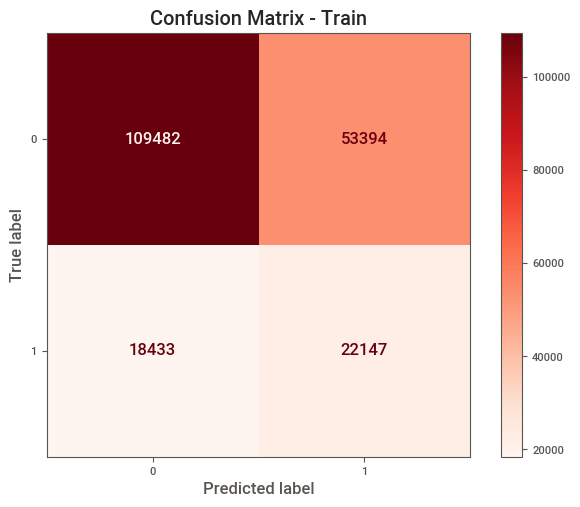

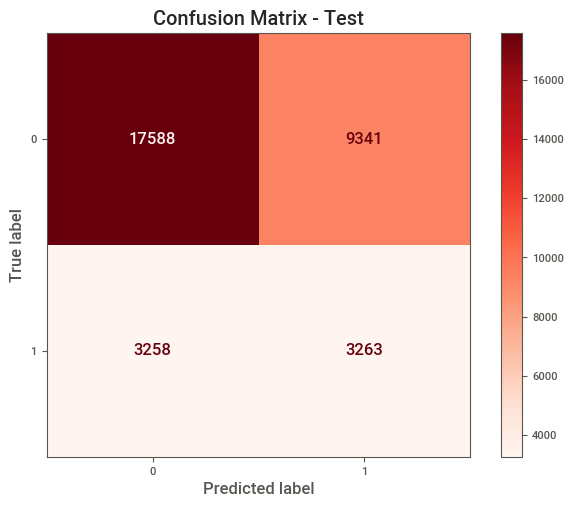

In [22]:
# Checking The Best Model Performance
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print('--- Classification Report: Train ---')
print(classification_report(y_train, y_pred_train))
print()

print('--- Classification Report: Test ---')
print(classification_report(y_test, y_pred_test))
print()

print('--- Confusion Matrix ---')
disp_train = ConfusionMatrixDisplay.from_estimator(model, X_train, y_train, cmap='Reds')
disp_train.ax_.set_title('Confusion Matrix - Train')
plt.show()

disp_test = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Reds')
disp_test.ax_.set_title('Confusion Matrix - Test')
plt.show()

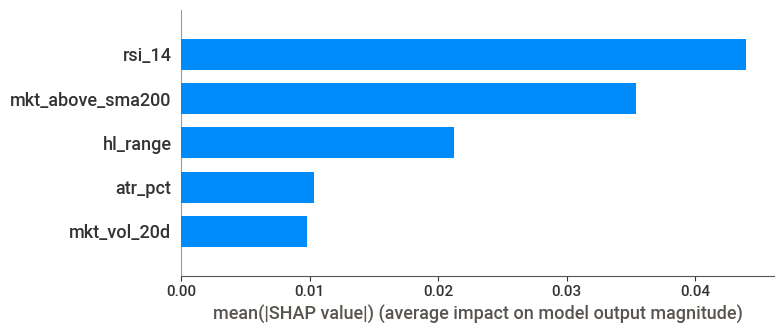

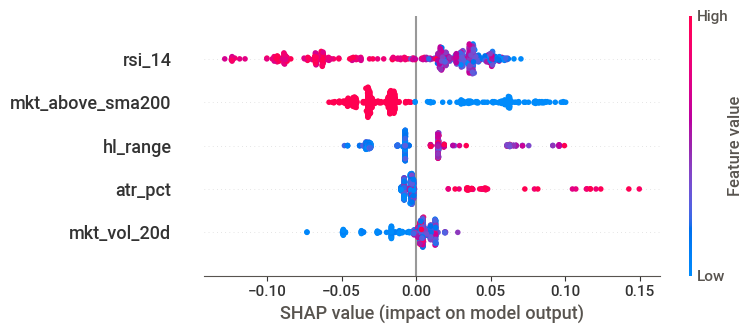

SHAP Importance Values:


,feature,mean_abs_shap
31,rsi_14,0.043920
55,mkt_above_sma200,0.035405
9,hl_range,0.021198
29,atr_pct,0.010316
56,mkt_vol_20d,0.009780
14,dist_ema_10,0.008448
46,vpt,0.007799
57,beta_60d,0.006122
21,crossover_ema_5_20,0.005141
6,body_size,0.003531


In [23]:
# Model Extraction
et_estimator = model[-1] 

# Sampling
X_val_df = X_train
sample_size = min(500, len(X_val_df))
X_sample = X_val_df.sample(n=sample_size, random_state=10)

# SHAP Explainer
explainer = shap.TreeExplainer(et_estimator)
shap_results = explainer.shap_values(X_sample)

if isinstance(shap_results, list):
    shap_values_to_plot = shap_results[1]
elif len(np.shape(shap_results)) == 3:
    shap_values_to_plot = shap_results[:, :, 1]
else:
    shap_values_to_plot = shap_results

# Visualization
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_plot, X_sample, plot_type="bar", max_display=5)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_plot, X_sample, max_display=5)

# Importance Value
mean_shap_values = np.abs(shap_values_to_plot).mean(axis=0)

shap_importance = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_abs_shap': mean_shap_values
}).sort_values('mean_abs_shap', ascending=False)

print("SHAP Importance Values:")
display(shap_importance.head(50))

In [24]:
# Feature Experiment Design
feature_exp = [len(X_train.columns), 40, 30, 23, 20, 15, 10]
model_exp = []

# Experiment
for n_fitur in feature_exp:
    top_features = shap_importance['feature'].head(n_fitur).tolist()
    X_train_subset = X_train[top_features]
    X_test_subset = X_test[top_features]
    
    model_eksperimen = ExtraTreesClassifier(
        n_estimators=500,
        class_weight='balanced',
        max_depth=6,
        max_leaf_nodes=31,
        random_state=42,
        n_jobs=-1
    )
    
    model_eksperimen.fit(X_train_subset, y_train)
    y_train_pred = model_eksperimen.predict(X_train_subset)
    y_test_pred = model_eksperimen.predict(X_test_subset)
    
    model_exp.append({
        'Jumlah Fitur': n_fitur,
        'Train Precision': precision_score(y_train, y_train_pred, zero_division=0),
        'Test Precision': precision_score(y_test, y_test_pred, zero_division=0),
        'Train Recall': recall_score(y_train, y_train_pred, zero_division=0),
        'Test Recall': recall_score(y_test, y_test_pred, zero_division=0),
        'Train F1-Score': f1_score(y_train, y_train_pred, zero_division=0),
        'Test F1-Score': f1_score(y_test, y_test_pred, zero_division=0)
    })

df_exp = pd.DataFrame(model_exp)

print("\n--- Experiment Result ---")
display(df_exp.round(3))


--- Experiment Result ---


,Jumlah Fitur,Train Precision,Test Precision,Train Recall,Test Recall,Train F1-Score,Test F1-Score
0,65,0.292,0.262,0.556,0.519,0.383,0.348
1,40,0.290,0.262,0.566,0.517,0.384,0.348
2,30,0.289,0.262,0.569,0.531,0.384,0.351
3,23,0.288,0.262,0.571,0.526,0.383,0.350
4,20,0.288,0.261,0.568,0.522,0.382,0.348
5,15,0.288,0.261,0.542,0.501,0.376,0.343
6,10,0.286,0.260,0.545,0.500,0.375,0.342


# 8. The Best Model

In [ ]:
# The Best Number of Features
n_features = 30
top_30_features = shap_importance['feature'].head(n_features).tolist()
top_30_features

['rsi_14',
 'mkt_above_sma200',
 'hl_range',
 'atr_pct',
 'mkt_vol_20d',
 'dist_ema_10',
 'vpt',
 'beta_60d',
 'crossover_ema_5_20',
 'body_size',
 'volatility_10d',
 'sma20_slope_5d',
 'return_20d',
 'dist_r1',
 'cmf_20',
 'williams_r',
 'return_1d',
 'volatility_5d',
 'dist_sma_10',
 'volatility_20d',
 'upper_shadow',
 'crossover_sma_50_200',
 'return_5d',
 'dist_s1',
 'cci_20',
 'vol_ratio',
 'vol_change_1d',
 'obv',
 'adl',
 'dist_r2']

In [ ]:
# The Best Model Hyperparameter
model = ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight='balanced',
                     criterion='gini', max_depth=3, max_features='log2',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=5,
                     min_samples_split=20, min_weight_fraction_leaf=0.0,
                     n_estimators=100, n_jobs=-1, oob_score=False,
                     random_state=42, verbose=0, warm_start=False
)